In [ ]:
!pip install google-cloud-translate

In [ ]:
api_key = "###"

In [ ]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import re
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from sklearn.manifold import TSNE
from tqdm import tqdm
import plotly.express as px
import requests
import time

In [ ]:
# mount google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# Load the dataset
pm_india_df = pd.read_csv("/content/drive/MyDrive/News_Analysis_Data/PM-all-speech/combined_translations.csv")
pm_india_df.head()

,English,assamese,bengali,gujarati,hindi,kannada,malayalam,meitei,marathi,oriya,punjabi,tamil,telugu,urdu
0,He held the position as the Chief Minister of ...,তেওঁৰ বিয়োগত তামিলনাডুৰ জনসাধাৰণে তেওঁলোকৰ এগৰ...,তিনি পাঁচ বার তামিলনাড়ুর মুখ্যমন্ত্রী পদে দায়ি...,તેઓ પાંચ વાર તમિલનાડુનાં મુખ્યમંત્રી બન્યાં હતાં.,वे पांच बार तमिलनाडु के मुख्‍यमंत्री रहे।,ನಂತರ ಐದು ಬಾರಿ ಅವರು ತಮಿಳುನಾಡು ಮುಖ್ಯಮಂತ್ರಿ ಸ್ಥಾನ...,അഞ്ചുതവണ തമിഴ്‌നാട് മുഖ്യമന്ത്രിസ്ഥാനം അദ്ദേഹം...,মহাক মঙারক হন্না তমিলনাদুগী মুখ্য মন্ত্রী ওইখি।,त्यांनी पाचवेळा तामिळनाडूचे मुख्यमंत्रीपद भूषवले.,ସେ ପାଞ୍ଚ ଥର ତାମିଲନାଡ଼ୁର ମୁଖ୍ୟମନ୍ତ୍ରୀ ରହିଥିଲେ ।,ਉਹ ਪੰਜ ਵਾਰ ਤਮਿਲਨਾਡੂ ਦੇ ਮੁੱਖ ਮੰਤਰੀ ਰਹੇ।,தமிழ்நாட்டில் முதலமைச்சராக அவர் ஐந்து முறை பதவ...,త‌మిళ‌నాడు రాష్ట్ర ముఖ్య‌మంత్రిగా ఆయ‌న ఐదు ప‌ర...,وہ پانچ مرتبہ تامل ناڈو کے وزیراعلی رہے۔
1,These include: Pradhan Mantri Awas Yojana (Urb...,সেইবোৰ হ’ল-প্ৰধানমন্ত্ৰী আৱাস যোজনা(নগৰ); নগৰ ...,"এগুলি হ’ল – প্রধানমন্ত্রী আবাস যোজনা (পুর), পু...","શહેરી વિકાસ અંતર્ગત પ્રધાનમંત્રી આવાસ યોજના, અ...","शहरी विकास के तहत प्रधानमंत्री आवास योजना, अमृ...","ಅವುಗಳೆಂದರೆ ಪ್ರಧಾನ ಮಂತ್ರಿ ಆವಾಸ್ ಯೋಜನಾ (ನಗರ) , ಅ...","പ്രധാനമന്ത്രി ആവാസ് യോജന (അര്‍ബന്‍), അടല്‍ മിഷ...",স্কিমশিং অদুদি : প্রধান মন্ত্রী অৱাস য়োজনা(অরব...,"यात प्रधानमंत्री आवास योजना, अमृत योजना आणि स्...",ଏଥି ମଧ୍ୟରେ ସହରୀ ବିକାଶ ଅନ୍ତର୍ଗତ ପ୍ରଧାନମନ୍ତ୍ରୀ ଆ...,ਇਹ ਪਹਿਲਾਂ ਹਨ – ਪ੍ਰਧਾਨ ਮੰਤਰੀ ਆਵਾਸ ਯੋਜਨਾ (ਸ਼ਹਿਰੀ)...,பிரதம மந்திரி வீட்டுவசதி திட்டம் (நகர்ப்புறம்)...,ఫ్లాగ్‌షిప్ కార్య‌క్ర‌మాలైన‌ అట‌ల్ మిష‌న్ ఫ‌ర్...,یہ تین اسکیمیں ہیں : پردھان منتری آواس یوجنا (...
2,"Prime Minister, Shri Narendra Modi paid tribut...",মহাত্মা গান্ধী আৰু লাল বাহাদুৰ শাস্ত্ৰীৰ জন্ম ...,প্রধানমন্ত্রী শ্রী নরেন্দ্র মোদী মহাত্মা গান্ধ...,પ્રધાનમંત્રી શ્રી નરેન્દ્ર મોદીએ મહાત્મા ગાંધી...,प्रधानमंत्री श्री नरेंद्र मोदी ने महात्मा गांध...,ಮಹತ್ಮಾ ಗಾಂಧಿ ಮತ್ತು ಲಾಲ್ ಬಹಾದುರ್ ಶಾಸ್ತ್ರಿ ಅವರುಗ...,ജന്മദിനത്തില്‍ മഹാത്മാ ഗാന്ധിക്കും ലാല്‍ ബഹദൂര...,প্রধানমন্ত্রী শ্রী নরেন্দ্র মোদীনা মহাত্মা গান...,पंतप्रधान नरेंद्र मोदी यांनी राष्ट्रपिता महात्...,ମହାତ୍ମା ଗାନ୍ଧୀ ଏବଂ ଲାଲ ବାହାଦୁର ଶାସ୍ତ୍ରୀଙ୍କ ଜନ୍...,"ਪ੍ਰਧਾਨ ਮੰਤਰੀ, ਸ਼੍ਰੀ ਨਰੇਂਦਰ ਮੋਦੀ ਨੇ ਮਹਾਤਮਾ ਗਾਂਧ...",மகாத்மா காந்தி மற்றும் லால் பகதூர் சாஸ்திரியின...,"మ‌హాత్మ గాంధీ కి, లాల్ బహాదుర్ శాస్త్రి గారికి...",نئی دہلی ،2اکتوبر :وزیراعظم ، جناب نریندرمودی ...
3,The Prime Minister praised the Vice President ...,প্ৰধানমন্ত্ৰীয়ে ইংৰাজী অথবা তেলেগু ভাষাত ভেংকা...,শ্রী মোদী রাষ্ট্রপতির ইংরেজী ও তেলেগু ভাষায় বা...,પ્રધાનમંત્રીએ ઉપરાષ્ટ્રપતિની તેમના વકતૃત્વ માટ...,प्रधानमंत्री ने उपराष्ट्रपति की भाषण कला एवं उ...,"ಇಂಗ್ಲೀಷ್ ಆಗಲಿ ಅಥವಾ ತೆಲುಗು ಆಗಿರಲಿ, ಉಪರಾಷ್ಟ್ರಪತಿ...",ഇംഗ്ലീഷിലായാലും തെലുങ്കിലായാലും മികച്ച രീതിയില...,প্রধান মন্ত্রীনা উপরাস্ত্রপতিগী ৱা ঙাংবগী কলা ...,पंतप्रधानांनी उपराष्ट्रपतींच्या भाषण शैलीची आण...,"ପ୍ରଧାନମନ୍ତ୍ରୀ, ଉପରାଷ୍ଟ୍ରପତିଙ୍କ ଭାଷଣ କଳା ତାହା ଇ...",ਪ੍ਰਧਾਨ ਮੰਤਰੀ ਨੇ ਉਪ ਰਾਸ਼ਟਰਪਤੀ ਦੀ ਭਾਸ਼ਣ ਕਲਾ ਅਤੇ ਉਨ...,குடியரசு துணைத் தலைவரின் பேச்சாற்றல் குறித்தும...,"ఉప రాష్ట్రప‌తి మౌఖిక ప్రావీణ్యాన్ని గురించి, త...",وزیراعظم نے نائب صدر جمہوریہ کے خطاب کے ہنر او...
4,"The Prime Minister, Shri Narendra Modi, will v...",প্ৰধানমন্ত্ৰী শ্ৰী নৰেন্দ্ৰ মোদীয়ে ১৬ মাৰ্চত ম...,"আগামীকাল, অর্থাৎ ১৬ মার্চ মণিপুর সফরে যাচ্ছেন ...","પ્રધાનમંત્રી શ્રી નરેન્દ્ર મોદી 16 માર્ચ, 2018...","प्रधानमंत्री श्री नरेन्‍द्र मोदी 16 मार्च, 201...",ಪ್ರಧಾನಮಂತ್ರಿ ಶ್ರೀ ನರೇಂದ್ರ ಮೋದಿ ಅವರು 2018ರ ಮಾರ್...,നരേന്ദ്ര മോദി നാളെ (2018 മാര്‍ച്ച് 16) മണിപ്പൂ...,২০১৮গী মার্চ ১৬তা প্রধান মন্ত্রী নরেন্দ্র মোদী...,पंतप्रधान नरेंद्र मोदी 16 मार्च 2018 रोजी मणिप...,ପ୍ରଧାନମନ୍ତ୍ରୀ ଶ୍ରୀ ନରେନ୍ଦ୍ର ମୋଦୀ 16 ମାର୍ଚ୍ଚ 20...,"ਪ੍ਰਧਾਨ ਮੰਤਰੀ ਸ਼੍ਰੀ ਨਰੇਂਦਰ ਮੋਦੀ 16 ਮਾਰਚ, 2018 ਨ...","மார்ச் 16, 2018 அன்று பிரதமர் நரேந்திர மோடி மண...","ప్ర‌ధాన మంత్రి శ్రీ న‌రేంద్ర మోదీ 2018, మార్చి...",نئی دہلی،15مارچ / وزیراعظم جناب نریندر مودی 16...


# Translations using Google Translate for all the language which are not English



In [ ]:
tqdm.pandas()

# Translate using Google Cloud Translation API
def translate_to_english(text, source_lang, api_key):
    try:
        if not isinstance(text, str) or text.strip() == "":
            return None

        url = "https://translation.googleapis.com/language/translate/v2"
        params = {
            "q": text,
            "source": source_lang,
            "target": "en",
            "key": api_key,
            "format": "text"
        }

        response = requests.post(url, data=params)
        if response.status_code == 200:
            return response.json()["data"]["translations"][0]["translatedText"]
        else:
            print(f"Error: {response.status_code} - {response.text}")
            return None
    except Exception as e:
        print(f"Error translating from {source_lang}: {text[:50]}..., Error: {e}")
        return None

In [ ]:
# Create a new DataFrame and copy original English column
pm_ind_translated_df = pd.DataFrame()
pm_ind_translated_df["original_english"] = pm_india_df["English"]

In [ ]:
# Google Translate language codes
lang_map = {
    "meitei": "mni-Mtei", "oriya": "or", "hindi": "hi", "tamil": "ta", "bengali": "bn", "urdu": "ur",
    "assamese": "as", "marathi": "mr", "telugu": "te", "gujarati": "gu", "punjabi": "pa",
    "kannada": "kn", "malayalam": "ml"
}

# Translate each language column using Google Translate API
for lang, code in lang_map.items():
    target_col = f"{lang}_en_translation"
    print(f"Translating from {lang} ({code}) to English...")
    pm_ind_translated_df[target_col] = pm_india_df[lang].progress_apply(lambda x: translate_to_english(x, code, api_key))
    time.sleep(1)  


Translating from meitei (mni-Mtei) to English...


100%|██████████| 201/201 [00:20<00:00, 10.02it/s]


Translating from oriya (or) to English...


100%|██████████| 201/201 [00:18<00:00, 11.14it/s]


Translating from hindi (hi) to English...


...

100%|██████████| 201/201 [00:18<00:00, 10.91it/s]


Translating from kannada (kn) to English...


100%|██████████| 201/201 [00:18<00:00, 10.81it/s]


Translating from malayalam (ml) to English...


100%|██████████| 201/201 [00:19<00:00, 10.14it/s]


In [ ]:
# save translated_DF
pm_ind_translated_df.to_csv("/content/drive/MyDrive/News_Analysis_Data/translated_PM_INDIA_WITH_GOOGLE_API.csv", index=True)

In [ ]:
pm_ind_translated_df = pd.read_csv("/content/drive/MyDrive/News_Analysis_Data/translated_PM_INDIA_WITH_GOOGLE_API.csv")

# Geenrate Embedddings using MPNet


In [ ]:
# check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [ ]:
model = SentenceTransformer("sentence-transformers/all-mpnet-base-v2").to(device)


In [ ]:
pm_ind_translated_df.head()

,original_english,meitei_en_translation,oriya_en_translation,hindi_en_translation,tamil_en_translation,bengali_en_translation,urdu_en_translation,assamese_en_translation,marathi_en_translation,telugu_en_translation,gujarati_en_translation,punjabi_en_translation,kannada_en_translation,malayalam_en_translation
0,He held the position as the Chief Minister of ...,He was the Chief Minister of Tamil Nadu on Tue...,He was the Chief Minister of Tamil Nadu five t...,He was the Chief Minister of Tamil Nadu five t...,He has served as Chief Minister of Tamil Nadu ...,He has served as the Chief Minister of Tamil N...,He was the Chief Minister of Tamil Nadu five t...,"In his death, the people of Tamil Nadu have lo...",He served as the Chief Minister of Tamil Nadu ...,He served five terms as the Chief Minister of ...,He became the Chief Minister of Tamil Nadu fiv...,He was the Chief Minister of Tamil Nadu five t...,He later served as the Chief Minister of Tamil...,He has served as the Chief Minister of Tamil N...
1,These include: Pradhan Mantri Awas Yojana (Urb...,Skimshing Adudi : Prime Minister Housing Schem...,"Among these, the Pradhan Mantri Awas Yojana (C...",Urban development includes Pradhan Mantri Awas...,These three schemes are the Prime Minister's H...,"These are – Pradhan Mantri Awas Yojana (PUR), ...",These three schemes are: Pradhan Mantri Awas Y...,They are Pradhan Mantri Awas Yojana (Urban); A...,"These include the Pradhan Mantri Awas Yojana, ...",The event was organized to mark the third anni...,Urban development includes Pradhan Mantri Awas...,These are the first – Pradhan Mantri Awas Yoja...,"These are Pradhan Mantri Awas Yojana (Urban), ...","These are Pradhan Mantri Awas Yojana (Urban), ..."
2,"Prime Minister, Shri Narendra Modi paid tribut...",Prime Minister Shri Narendra Modi inaugurates ...,Prime Minister Shri Narendra Modi has paid tri...,"The Prime Minister, Shri Narendra Modi paid tr...",The Prime Minister paid tributes to Mahatma Ga...,"The Prime Minister, Shri Narendra Modi, paid t...","New Delhi, October 2: The Prime Minister, Shri...",Prime Minister Shri Narendra Modi pays tribute...,Prime Minister Narendra Modi paid heartfelt tr...,Prime Minister Shri Narendra Modi paid tribute...,"The Prime Minister, Shri Narendra Modi, paid t...","The Prime Minister, Shri Narendra Modi, paid t...",Prime Minister Shri Narendra Modi paid tribute...,Prime Minister Shri Narendra Modi has paid tri...
3,The Prime Minister praised the Vice President ...,Prime Minister Vice President Wa Ngangbagi Kal...,The Prime Minister praised the Vice President'...,The Prime Minister appreciated the oratory ski...,The Prime Minister praised the Vice President'...,Shri Modi praised the President's fluency in E...,The Prime Minister praised the Vice President'...,The Prime Minister praised the vocabulary used...,The Prime Minister praised the Vice President'...,The Prime Minister praised the Vice President ...,The Prime Minister praised the Vice President ...,The Prime Minister praised the Vice President'...,The Prime Minister praised the Vice President ...,The Prime Minister praised the Vice President ...
4,"The Prime Minister, Shri Narendra Modi, will v...",Prime Minister Narendra Modi visits Manipur on...,Prime Minister Shri Narendra Modi will visit M...,Prime Minister Shri Narendra Modi will visit M...,Prime Minister Narendra Modi is scheduled to v...,Prime Minister Shri Narendra Modi will visit M...,"New Delhi, March 15 / Prime Minister Shri Nare...",Prime Minister Shri Narendra Modi will visit M...,Prime Minister Narendra Modi will visit Manipu...,Prime Minister Shri Narendra Modi will visit M...,Prime Minister Shri Narendra Modi will visit M...,Prime Minister Shri Narendra Modi will visit M...,Prime Minister Shri Narendra Modi will visit M...,Narendra Modi will visit Manipur tomorrow (Mar...


In [ ]:
# remove unamed coloum
pm_ind_translated_df = pm_ind_translated_df.loc[:, ~pm_ind_translated_df.columns.str.contains('^Unnamed')]

In [ ]:
# Store all row-wise embeddings in a list
pm_ind_embeddings = []

# Generate embeddings row-wise
for _, row in tqdm(pm_ind_translated_df.iterrows(), total=pm_ind_translated_df.shape[0], desc="Generating embeddings"):
    sentence_list = row.astype(str).tolist() 
    embeddings = model.encode(sentence_list)
    pm_ind_embeddings.append(embeddings)  # shape: [num_languages, embedding_dim]


Generating embeddings: 100%|██████████| 201/201 [00:06<00:00, 29.18it/s]


In [ ]:
# create a DataFrame with same shape as original to store embeddings
pm_ind_embeddings_df = pd.DataFrame(index=pm_ind_translated_df.index, columns=pm_ind_translated_df.columns)

# fill the DataFrame using the precomputed embeddings
for row_idx, row_embeddings in enumerate(pm_ind_embeddings):
    for col_idx, lang in enumerate(pm_ind_translated_df.columns):
        pm_ind_embeddings_df.at[row_idx, lang] = row_embeddings[col_idx]

In [ ]:
pm_ind_embeddings_df.head()


,original_english,meitei_en_translation,oriya_en_translation,hindi_en_translation,tamil_en_translation,bengali_en_translation,urdu_en_translation,assamese_en_translation,marathi_en_translation,telugu_en_translation,gujarati_en_translation,punjabi_en_translation,kannada_en_translation,malayalam_en_translation
0,"[0.017640213, -0.04251205, -0.013361652, 0.036...","[0.010685823, -0.046815787, -0.008331199, 0.04...","[0.022670545, -0.031704128, -0.012490599, 0.03...","[0.022670545, -0.031704128, -0.012490599, 0.03...","[0.010580412, -0.029566767, -0.01742239, 0.050...","[0.009959093, -0.03306523, -0.016606608, 0.048...","[0.022670545, -0.031704128, -0.012490599, 0.03...","[0.0169082, 0.05043477, -0.009348627, -0.00411...","[0.017009135, -0.0396254, -0.013445297, 0.0409...","[-0.0014172482, -0.03726135, -0.0074700094, 0....","[0.019214654, -0.034706336, -0.012256226, 0.02...","[0.022670545, -0.031704128, -0.012490599, 0.03...","[0.019219367, -0.037247904, -0.013363011, 0.03...","[0.009959093, -0.03306523, -0.016606608, 0.048..."
1,"[0.007889292, -0.0057770642, -0.008328717, -0....","[-0.037959643, -0.018114982, -0.031952042, 0.0...","[0.010426096, -0.026210269, -0.008604339, -0.0...","[-0.045197822, 0.029350786, -0.02640164, 0.003...","[0.012332619, -0.019650245, -0.014678556, -0.0...","[0.016093263, 0.0045198835, -0.0027434903, -0....","[0.033529934, -0.032477647, -0.021177389, -0.0...","[0.008152109, -0.0050998162, -0.014901539, 0.0...","[-0.012099327, -0.034867663, -0.020130368, -0....","[0.00052136666, 0.007575854, -0.0164771, 0.033...","[-0.043014873, 0.018458655, -0.020554595, 0.00...","[0.017966617, -0.011827985, -0.014884785, -0.0...","[-0.017630203, -0.012164825, -0.02082039, -0.0...","[-0.00867297, -0.028618183, -0.014202012, -0.0..."
2,"[-0.018825155, 0.043602526, -0.023480987, -0.0...","[-0.016887005, 0.051826876, -0.01473076, 0.017...","[-0.018018285, 0.04905386, -0.0249792, -0.0173...","[-0.022765536, 0.04455168, -0.02487643, -0.005...","[-0.03267502, 0.013548126, -0.029974263, 0.010...","[-0.01302444, 0.03571867, -0.0281757, -0.01020...","[-0.0146985175, 0.047766935, -0.028572371, -0....","[-0.019186357, 0.047760203, -0.029773248, -0.0...","[-0.018209532, 0.02839505, -0.023399401, 0.001...","[-0.020315679, 0.036020644, -0.027073562, -0.0...","[-0.022668334, 0.046081457, -0.024620708, -0.0...","[-0.023508629, 0.041792307, -0.02929539, -0.01...","[-0.020315679, 0.036020644, -0.027073562, -0.0...","[-0.01813753, 0.051252592, -0.021451203, -0.01..."
3,"[0.00147823, -0.031638704, -0.0071934047, 0.04...","[0.03588508, -0.0108133955, -0.010306896, 0.03...","[0.009576952, -0.02601479, 0.0006520779, 0.042...","[0.014647409, -0.013141495, -0.003860525, 0.03...","[0.01074537, -0.04095657, -0.0074365996, 0.033...","[-0.018410038, -0.009452359, -0.03171258, 0.04...","[0.0061485963, -0.024279386, -0.009638297, 0.0...","[-0.0008766367, -0.001957342, -0.024095364, 0....","[0.007039284, -0.039686594, -0.018188594, 0.04...","[0.01662093, -0.036393277, -0.017818427, 0.042...","[0.0112929065, -0.03757995, 0.0008780215, 0.04...","[0.006038415, -0.025640402, -0.0014118636, 0.0...","[0.016618563, -0.046586744, -0.016403275, 0.05...","[-0.022736074, -0.028589075, -0.023961565, 0.0..."
4,"[0.0118128285, 0.043593593, -0.043022167, 0.01...","[-0.0016978332, 0.028282259, -0.048092335, 0.0...","[0.013605934, 0.04579852, -0.03878899, -0.0121...","[0.013410179, 0.044371955, -0.03756469, -0.011...","[0.013456051, 0.050392874, -0.039496828, -0.01...","[-0.0028877228, 0.016862707, -0.03312821, -0.0...","[0.01157168, 0.040542055, -0.036101118, -0.020...","[0.0022735132, 0.03342189, -0.039205242, -0.01...","[0.015884971, 0.04829095, -0.03586516, -0.0117...","[0.01303745, 0.043841455, -0.037572674, -0.011...","[0.013163671, 0.041332357, -0.03678127, -0.010...","[0.013410179, 0.044371955, -0.03756469, -0.011...","[0.01303745, 0.043841455, -0.037572674, -0.011...","[0.0025098163, 0.025888436, -0.036128223, -0.0..."


# t-SNE Dimesionality Reduction

In [ ]:
def prepare_tsne_data(df):
    data = []
    labels = []
    row_indices = []

    for row_idx, row in df.iterrows():
        for lang in df.columns:
            embedding = row[lang]
            data.append(embedding)
            labels.append(lang)
            row_indices.append(row_idx)

    return np.array(data), labels, row_indices

In [ ]:
# Prepare
all_embeddings, languages, row_ids = prepare_tsne_data(pm_ind_embeddings_df)

tsne = TSNE(
    n_components=2,
    perplexity=5,
    max_iter=2000,
    learning_rate=100,
    metric="cosine",
    random_state=42
)

tsne_result = tsne.fit_transform(all_embeddings)

# Make DataFrame
tsne_df = pd.DataFrame({
    'x': tsne_result[:, 0],
    'y': tsne_result[:, 1],
    'Language': languages,
    'Row': row_ids
})


In [ ]:
fig = px.scatter(
    tsne_df,
    x='x',
    y='y',
    color='Row',
    hover_data=['Language', 'Row'],
    title="t-SNE of Multilingual Sentence Embeddings by MPNet (Colored by Row)",

)
fig.update_traces(marker=dict(size=6, opacity=0.8))
fig.show()

In [ ]:

fig = px.scatter(
    tsne_df,
    x='x',
    y='y',
    color='Language',
    hover_data=['Language', 'Row'],
    title="Global t-SNE of Multilingual Sentence Embeddings using MPNet (Colored by Language)",

)
fig.update_traces(marker=dict(size=6, opacity=0.8))
fig.show()

In [ ]:
# Filter only Row 0
row_0_df = tsne_df[tsne_df["Row"] == 0]

# Plot
fig = px.scatter(
    row_0_df,
    x='x',
    y='y',
    color='Language',
    hover_data=['Language'],
    title='t-SNE Semantic Map for Row 0 (Same Sentence Across Languages)',

)

fig.update_traces(marker=dict(size=10, opacity=0.9))
fig.update_layout(showlegend=True)
fig.show()


# Cosine Similarity with original 768-D embeddings

In [ ]:
similarity_matrices = []  # to hold similarity matrix per sentence

for idx, row in pm_ind_embeddings_df.iterrows():
    embeddings = np.array(row.tolist())  # shape: [num_languages, embedding_dim]
    sim_matrix = cosine_similarity(embeddings)  # shape: [num_langs x num_langs]
    similarity_matrices.append(sim_matrix)

In [ ]:
# Stack all matrices: shape becomes [num_rows, num_langs, num_langs]
similarity_stack = np.stack(similarity_matrices)

# Mean similarity matrix across all rows
avg_similarity_matrix = np.mean(similarity_stack, axis=0)


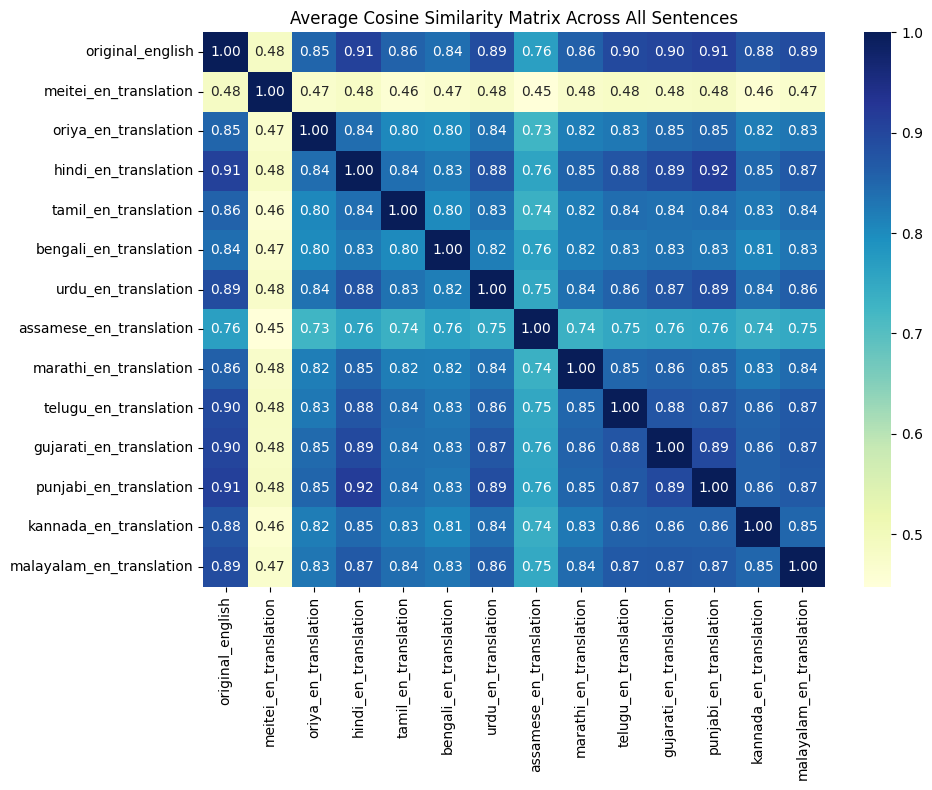

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(avg_similarity_matrix, annot=True, fmt=".2f",
            xticklabels=pm_ind_embeddings_df.columns.tolist(),
            yticklabels=pm_ind_embeddings_df.columns.tolist(),
            cmap="YlGnBu")
plt.title("Average Cosine Similarity Matrix Across All Sentences")
plt.tight_layout()
plt.show()


# Cosine Similarity on t-SNE reduced embeddings

In [ ]:
tsne_wide_df = (
    tsne_df
    .assign(coords=lambda df: df[['x', 'y']].values.tolist())
    .pivot(index='Row', columns='Language', values='coords')
)


In [ ]:
tsne_wide_df.head()

Language,assamese_en_translation,bengali_en_translation,gujarati_en_translation,hindi_en_translation,kannada_en_translation,malayalam_en_translation,marathi_en_translation,meitei_en_translation,original_english,oriya_en_translation,punjabi_en_translation,tamil_en_translation,telugu_en_translation,urdu_en_translation
Row,,,,,,,,,,,,,,
0,"[-108.01453399658203, 65.71778869628906]","[-112.25989532470703, 65.05648803710938]","[-108.2437973022461, 63.3231201171875]","[-108.77175903320312, 64.64772033691406]","[-109.55322265625, 63.24132537841797]","[-112.25989532470703, 65.05648803710938]","[-109.80445861816406, 64.00473022460938]","[-112.72940063476562, 65.88259887695312]","[-110.357177734375, 63.85127258300781]","[-108.77175903320312, 64.64772033691406]","[-108.77175903320312, 64.64772033691406]","[-112.29882049560547, 65.1200942993164]","[-110.48106384277344, 62.814308166503906]","[-108.77175903320312, 64.64772033691406]"
1,"[-2.5389652252197266, 85.81304931640625]","[-2.9275689125061035, 86.50605773925781]","[1.314177393913269, 82.24879455566406]","[1.2634466886520386, 82.28144073486328]","[-1.0689506530761719, 85.53913116455078]","[-2.0084280967712402, 86.09983825683594]","[-2.0497429370880127, 85.0521011352539]","[0.7804431319236755, 82.62464141845703]","[-2.215954065322876, 86.19620513916016]","[-0.7656134366989136, 86.07951354980469]","[-2.3120501041412354, 86.85994720458984]","[0.07183486968278885, 87.30410766601562]","[0.3059888780117035, 87.97409057617188]","[-0.009689023718237877, 87.20213317871094]"
2,"[-76.2094497680664, -9.648538589477539]","[-73.90587615966797, -11.492647171020508]","[-73.44218444824219, -10.048529624938965]","[-73.66276550292969, -9.921932220458984]","[-75.98571014404297, -9.914902687072754]","[-75.06085968017578, -8.97409725189209]","[-76.77696990966797, -10.754265785217285]","[-71.94619750976562, -9.604269027709961]","[-74.03518676757812, -9.67051887512207]","[-75.787109375, -9.366582870483398]","[-73.2142105102539, -10.731616973876953]","[-72.71554565429688, -11.594916343688965]","[-75.98571014404297, -9.914902687072754]","[-72.31694030761719, -10.245296478271484]"
3,"[-65.09031677246094, -91.37142181396484]","[-64.52639770507812, -92.03290557861328]","[-61.7236213684082, -91.8611068725586]","[-61.300498962402344, -90.50518035888672]","[-63.83721923828125, -90.88836669921875]","[-63.60331726074219, -92.25165557861328]","[-62.19289779663086, -89.24152374267578]","[-13.113348960876465, 30.367433547973633]","[-62.05202102661133, -91.39395141601562]","[-62.373260498046875, -90.67625427246094]","[-62.44771957397461, -90.69664764404297]","[-62.471717834472656, -90.37555694580078]","[-63.64511489868164, -89.58917999267578]","[-63.03334045410156, -91.23458862304688]"
4,"[-88.16567993164062, 17.580001831054688]","[-87.17395782470703, 13.92490005493164]","[-89.53231048583984, 15.970137596130371]","[-89.1557846069336, 16.77471351623535]","[-89.90574645996094, 16.026103973388672]","[-87.17290496826172, 13.922810554504395]","[-89.79174041748047, 17.825105667114258]","[-91.58263397216797, 18.71320915222168]","[-91.1766586303711, 18.45402717590332]","[-89.83887481689453, 16.8385066986084]","[-89.1557846069336, 16.77471351623535]","[-89.93843841552734, 18.414087295532227]","[-89.9058609008789, 16.026111602783203]","[-88.0674819946289, 16.247159957885742]"


In [ ]:
similarity_matrices_tsne = []  # to hold similarity matrix per sentence

for idx, row in tsne_wide_df.iterrows():
    embeddings = np.array(row.tolist())
    sim_matrix = cosine_similarity(embeddings)
    similarity_matrices_tsne.append(sim_matrix)

In [ ]:
# Stack all matrices: shape becomes [num_rows, num_langs, num_langs]
similarity_stack_tsne = np.stack(similarity_matrices_tsne)

# Mean similarity matrix across all rows
avg_similarity_matrix_tsne = np.mean(similarity_stack_tsne, axis=0)


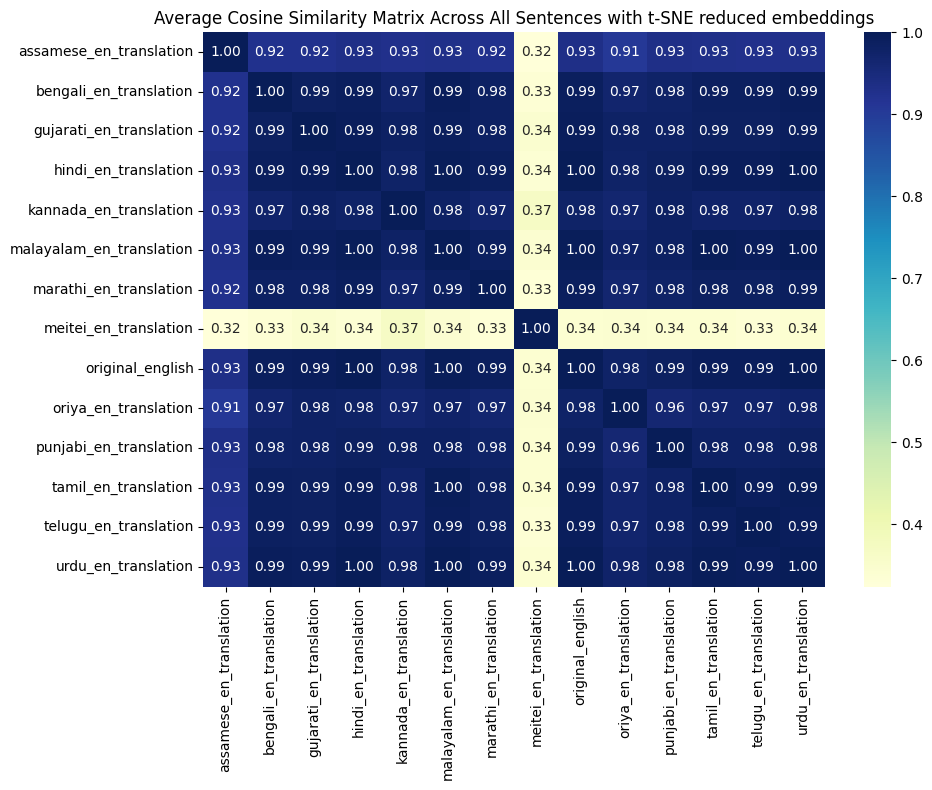

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(avg_similarity_matrix_tsne, annot=True, fmt=".2f",
            xticklabels=tsne_wide_df.columns.tolist(),
            yticklabels=tsne_wide_df.columns.tolist(),
            cmap="YlGnBu")
plt.title("Average Cosine Similarity Matrix Across All Sentences with t-SNE reduced embeddings")
plt.tight_layout()
plt.show()